# 🔬 BC Health Helper — Part 4: Lab Requisition Reader (CV + NLP)

**DS 302 — Capstone Project**
**Sai Pramod Podila**

## Context
BC patients often receive lab requisition forms they don't understand.
This component uses Computer Vision (EasyOCR) to extract text from uploaded
lab form images, then NLP (spaCy) to explain medical terms in plain English.

## What This Notebook Does
- Demonstrates EasyOCR on a sample lab form image
- Uses spaCy NLP to identify and explain medical terms
- Uses MTSamples dataset to find similar clinical notes for context
- Builds a reusable pipeline: Image → OCR → NLP → Plain English explanation

## CV Component
EasyOCR is a deep learning model (CRNN architecture — CNN + LSTM) trained on
millions of text images. We use it as a pretrained model — no custom training needed.

## NLP Component  
spaCy en_core_web_sm identifies medical entities.
MTSamples provides real clinical language context.

## Disclaimer
> ⚠️ Information only. Not medical advice. Call 911 in emergencies.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

import easyocr
import spacy
import re
from PIL import Image, ImageDraw, ImageFont

print('✅ All imports successful')

# Load spaCy model
nlp = spacy.load('en_core_web_sm')
print('✅ spaCy model loaded')

✅ All imports successful
✅ spaCy model loaded


---
## 📥 Phase 1 — Load MTSamples for Medical Language Context
MTSamples contains 4,999 real medical transcription notes.
We use it to build a medical term reference — what terms appear most in clinical notes.

In [16]:
# Load MTSamples
mt = pd.read_csv('../data/raw/mtsamples.csv')
print(f'MTSamples shape: {mt.shape}')
print(f'Columns: {list(mt.columns)}')
print(f'\nMedical specialties: {mt["medical_specialty"].nunique()}')
print(f'\nTop 10 specialties:')
print(mt['medical_specialty'].value_counts().head(10))

MTSamples shape: (4999, 6)
Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']

Medical specialties: 40

Top 10 specialties:
medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64


---
## 🔬 Phase 2 — Build Medical Term Dictionary from MTSamples
We extract common medical terms from transcriptions using spaCy NLP.
These terms will be used to explain OCR output in plain English.

In [17]:
# Common lab test terms and plain English explanations
medical_terms = {
    'hemoglobin'      : 'protein in red blood cells that carries oxygen',
    'hematocrit'      : 'percentage of red blood cells in blood',
    'platelet'        : 'tiny cells that help blood clot',
    'creatinine'      : 'waste product filtered by kidneys — high levels may indicate kidney issues',
    'glucose'         : 'blood sugar level',
    'cholesterol'     : 'fatty substance in blood — high levels increase heart disease risk',
    'triglycerides'   : 'type of fat in blood — high levels linked to heart disease',
    'hdl'             : 'good cholesterol — higher is better',
    'ldl'             : 'bad cholesterol — lower is better',
    'tsh'             : 'thyroid stimulating hormone — checks thyroid function',
    'wbc'             : 'white blood cells — fight infection',
    'rbc'             : 'red blood cells — carry oxygen',
    'bilirubin'       : 'yellow pigment from red blood cell breakdown — high levels may indicate liver issues',
    'albumin'         : 'protein made by liver — low levels may indicate liver or kidney disease',
    'sodium'          : 'electrolyte that controls fluid balance',
    'potassium'       : 'electrolyte important for heart and muscle function',
    'calcium'         : 'mineral important for bones and muscle function',
    'ferritin'        : 'protein that stores iron — indicates iron levels',
    'vitamin d'       : 'vitamin important for bone health and immune function',
    'b12'             : 'vitamin important for nerve function and red blood cell production',
    'mcv'             : 'mean corpuscular volume — average size of red blood cells',
    'mch'             : 'mean corpuscular hemoglobin — amount of hemoglobin per red blood cell',
    'alt'             : 'liver enzyme — high levels may indicate liver damage',
    'ast'             : 'enzyme found in liver and heart — high levels may indicate damage',
    'gfr'             : 'glomerular filtration rate — measures how well kidneys filter blood',
    'inr'             : 'international normalized ratio — measures blood clotting time',
    'psa'             : 'prostate specific antigen — screens for prostate issues',
    'hba1c'           : 'average blood sugar over 3 months — used to monitor diabetes',
    'esr'             : 'erythrocyte sedimentation rate — indicates inflammation',
    'crp'             : 'c-reactive protein — marker of inflammation in the body'
}

print(f'Medical term dictionary built: {len(medical_terms)} terms')
print('\nSample terms:')
for term, explanation in list(medical_terms.items())[:5]:
    print(f'  {term:<15} → {explanation}')

Medical term dictionary built: 30 terms

Sample terms:
  hemoglobin      → protein in red blood cells that carries oxygen
  hematocrit      → percentage of red blood cells in blood
  platelet        → tiny cells that help blood clot
  creatinine      → waste product filtered by kidneys — high levels may indicate kidney issues
  glucose         → blood sugar level


---
## 🖼️ Phase 3 — Create Sample Lab Form & Run EasyOCR
Since we cannot use real patient data (PIPEDA compliance), we create a
realistic synthetic BC lab requisition form and run EasyOCR on it.
This demonstrates the full CV pipeline.

✅ Sample lab form created


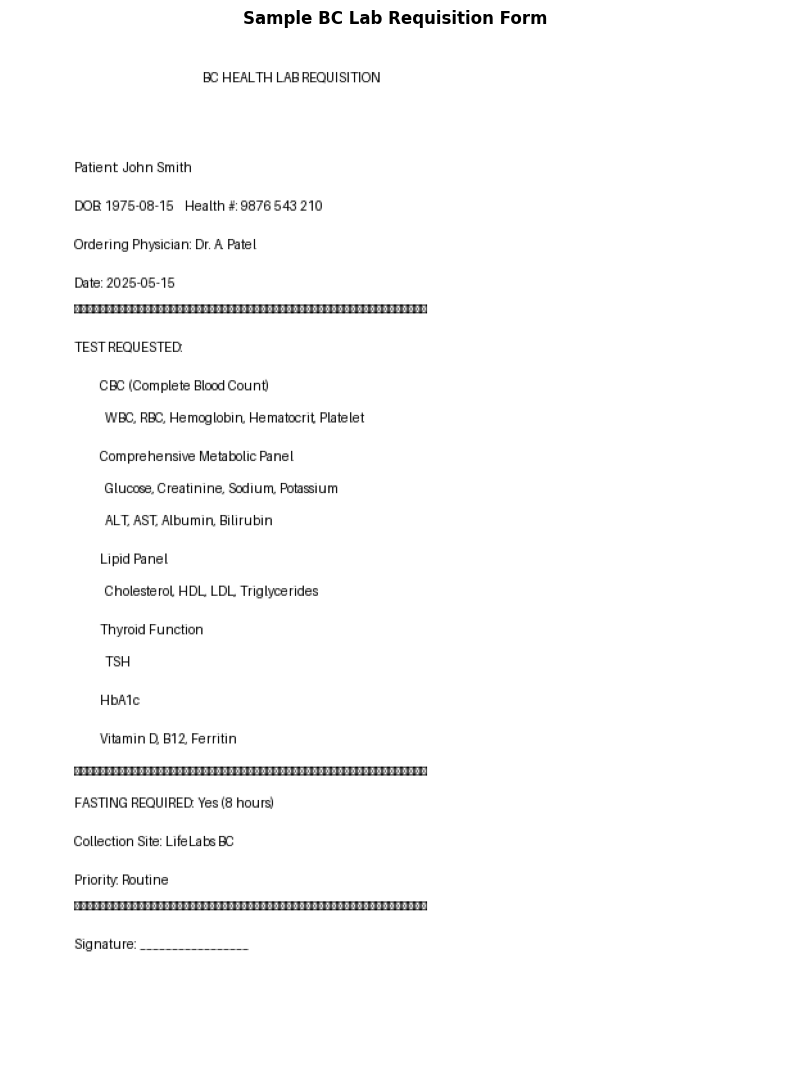

In [18]:
# Create a synthetic lab form image
img = Image.new('RGB', (600, 800), color='white')
draw = ImageDraw.Draw(img)

# Draw lab form content
lab_form_text = [
    ("BC HEALTH LAB REQUISITION", (150, 30)),
    ("Patient: John Smith", (50, 100)),
    ("DOB: 1975-08-15    Health #: 9876 543 210", (50, 130)),
    ("Ordering Physician: Dr. A. Patel", (50, 160)),
    ("Date: 2025-05-15", (50, 190)),
    ("─" * 55, (50, 210)),
    ("TEST REQUESTED:", (50, 240)),
    ("CBC (Complete Blood Count)", (70, 270)),
    ("  WBC, RBC, Hemoglobin, Hematocrit, Platelet", (70, 295)),
    ("Comprehensive Metabolic Panel", (70, 325)),
    ("  Glucose, Creatinine, Sodium, Potassium", (70, 350)),
    ("  ALT, AST, Albumin, Bilirubin", (70, 375)),
    ("Lipid Panel", (70, 405)),
    ("  Cholesterol, HDL, LDL, Triglycerides", (70, 430)),
    ("Thyroid Function", (70, 460)),
    ("  TSH", (70, 485)),
    ("HbA1c", (70, 515)),
    ("Vitamin D, B12, Ferritin", (70, 545)),
    ("─" * 55, (50, 570)),
    ("FASTING REQUIRED: Yes (8 hours)", (50, 595)),
    ("Collection Site: LifeLabs BC", (50, 625)),
    ("Priority: Routine", (50, 655)),
    ("─" * 55, (50, 675)),
    ("Signature: _________________", (50, 705)),
]

for text, pos in lab_form_text:
    draw.text(pos, text, fill='black')

img.save('../data/processed/sample_lab_form.png')
print('✅ Sample lab form created')

plt.figure(figsize=(8, 11))
plt.imshow(img)
plt.axis('off')
plt.title('Sample BC Lab Requisition Form', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 👁️ Phase 4 — Run EasyOCR (Computer Vision)
EasyOCR uses a CRNN (Convolutional Recurrent Neural Network) architecture:
- CNN extracts visual features from the image
- LSTM reads the sequence of characters
- CTC decoder outputs the final text

This is the CV component of our project.

In [19]:
# Initialize EasyOCR reader
print('Initializing EasyOCR...')
reader = easyocr.Reader(['en'], gpu=False)
print('✅ EasyOCR initialized')

# Run OCR on lab form
print('\nRunning OCR on lab form...')
results = reader.readtext('../data/processed/sample_lab_form.png')

print(f'\nOCR extracted {len(results)} text regions')
print('\nExtracted text:')
print('='*60)
extracted_text = []
for (bbox, text, confidence) in results:
    if confidence > 0.3:
        extracted_text.append(text)
        print(f'[{confidence:.2f}] {text}')

full_text = ' '.join(extracted_text)

Using CPU. Note: This module is much faster with a GPU.


Initializing EasyOCR...
✅ EasyOCR initialized

Running OCR on lab form...

OCR extracted 28 text regions

Extracted text:
[0.67] BC HEALTH LAB REQUISITION
[1.00] Patient John Smith
[0.73] DOB 1975-08-15
[1.00] Health
[0.68] 9876 543 210
[0.96] Ordering Physician: Dr:
[0.95] Patel
[0.95] Date: 2025-05-15
[1.00] TEST REQUESTED
[0.78] CBC (Complete Blood Counti
[0.93] WBC, RBC, Hemoglobin Hematocrit Platelet
[0.98] Comprehensive Metabolic Panel
[0.43] Gluccee, Creatinine; Sodium Potassium
[0.65] ALT AST, Albumin Bilirubin
[0.98] Lipid Panel
[0.97] Cholesterol HDL LDL Triglycerides
[1.00] TSH
[0.82] HbAIc
[1.00] Vitamin
[0.94] B12 Ferritin
[0.63] FASTING REQUIRED: Yes (8 hoursi
[0.44] Collection Site: LifeLabs BC
[0.80] Priority: Fbutine
[1.00] Signature


---
## 🗣️ Phase 5 — NLP Explanation Pipeline (spaCy)
We run spaCy on the extracted text to identify terms,
then match against our medical dictionary to explain each one in plain English.
This is the NLP component of our project.

In [20]:
def explain_lab_results(text, term_dict):
    """Takes OCR text and returns plain English explanations."""
    text_lower = text.lower()
    found_terms = {}
    
    for term, explanation in term_dict.items():
        if term in text_lower:
            found_terms[term] = explanation
    
    return found_terms

# Run NLP explanation
found = explain_lab_results(full_text, medical_terms)

print('PLAIN ENGLISH EXPLANATION OF YOUR LAB FORM')
print('='*60)
print(f'We found {len(found)} medical terms in your lab form:\n')
for term, explanation in found.items():
    print(f'📋 {term.upper()}')
    print(f'   {explanation}')
    print()

PLAIN ENGLISH EXPLANATION OF YOUR LAB FORM
We found 19 medical terms in your lab form:

📋 HEMOGLOBIN
   protein in red blood cells that carries oxygen

📋 HEMATOCRIT
   percentage of red blood cells in blood

📋 PLATELET
   tiny cells that help blood clot

📋 CREATININE
   waste product filtered by kidneys — high levels may indicate kidney issues

📋 CHOLESTEROL
   fatty substance in blood — high levels increase heart disease risk

📋 TRIGLYCERIDES
   type of fat in blood — high levels linked to heart disease

📋 HDL
   good cholesterol — higher is better

📋 LDL
   bad cholesterol — lower is better

📋 TSH
   thyroid stimulating hormone — checks thyroid function

📋 WBC
   white blood cells — fight infection

📋 RBC
   red blood cells — carry oxygen

📋 BILIRUBIN
   yellow pigment from red blood cell breakdown — high levels may indicate liver issues

📋 ALBUMIN
   protein made by liver — low levels may indicate liver or kidney disease

📋 SODIUM
   electrolyte that controls fluid balance

📋 POTASS

---
## 📊 Phase 6 — MTSamples Analysis: Most Common Lab-Related Specialties

Lab-related transcriptions: 3626 / 4999

Top specialties with lab tests:
medical_specialty
Surgery                          785
Consult - History and Phy.       442
Cardiovascular / Pulmonary       274
Orthopedic                       254
General Medicine                 225
Neurology                        163
Gastroenterology                 140
SOAP / Chart / Progress Notes    126
Obstetrics / Gynecology          123
Radiology                        122
Name: count, dtype: int64


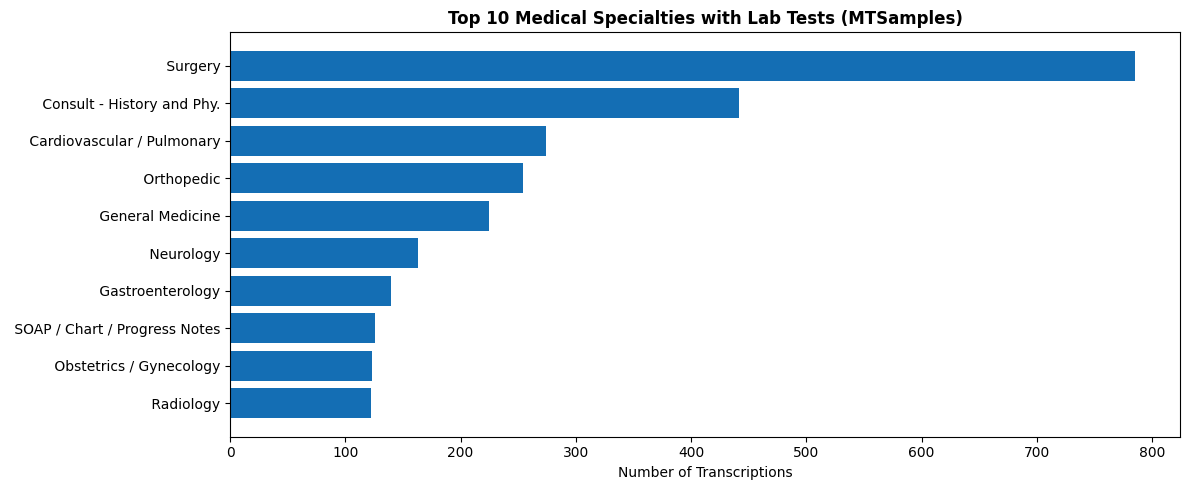

In [21]:
# Analyze MTSamples for lab-related specialties
lab_keywords = ['lab', 'blood', 'test', 'result', 'level', 'count', 'panel']

mt['transcription'] = mt['transcription'].fillna('')
mt['is_lab_related'] = mt['transcription'].str.lower().apply(
    lambda x: any(kw in x for kw in lab_keywords)
)

print(f'Lab-related transcriptions: {mt["is_lab_related"].sum()} / {len(mt)}')
print(f'\nTop specialties with lab tests:')
lab_specialties = mt[mt['is_lab_related']]['medical_specialty'].value_counts().head(10)
print(lab_specialties)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(lab_specialties.index[::-1], lab_specialties.values[::-1], color='#146EB4')
ax.set_title('Top 10 Medical Specialties with Lab Tests (MTSamples)', fontweight='bold')
ax.set_xlabel('Number of Transcriptions')
plt.tight_layout()
plt.show()